In [1]:
# %% [markdown]
# # NPxZxF Baseline Run
# Self-contained script for running the size-structured plankton model.
# All parameters are explicitly defined and can be modified before running.

# %% Imports
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import numpy as np
import xso

from npxzxf_comps import (
    Nutrient, PhytoSizeSpectrum, ZooSizeSpectrum,
    ConstantExternalNutrient, ConstantFishForcing,
    LinearForcingInput, MonodGrowth_SizeBased,
    SizebasedGrazingMatrix_Full_TypeIII, GGE_Full_SizeDep,
    PhytoMortality_toN, PhytoQuadMortality_toN, ZooQuadraticMortality,
    FishGrazing_SizeBased,
)


In [117]:
"""
Allometric Parameter Generator
===============================
Individual functions for each size-dependent parameter.
Scaling relationships follow Ward et al. (2012) and Banas (2011).
All inputs and outputs are based strictly on Equivalent Spherical Diameter (ESD).
"""

import numpy as np


def generate_size_classes(n, esd_min, esd_max):
    """Generate log-spaced size classes (µm ESD)."""
    return np.logspace(np.log10(esd_min), np.log10(esd_max), n)


# --- Phytoplankton ---------------------------------------------------------

def compute_m_P(esd):
    """
    Allometric mortality rate for phytoplankton (d-1).
    Uses a reference mortality of 0.5 at 1 µm and scales with ESD^(-0.75).
    """
    #old:return 0.5 * esd ** (-0.75)
    # 0.5 is your preferred baseline mortality at 1 µm
    return 0.5 * esd ** (-0.45)


def compute_m_virus(esd):
    """
    Quadratic mortality coefficient (m3 mmol N-1 d-1) representing viral lysis.
    Penalizes SMALL cells due to higher numerical abundance and susceptibility.
    Applied in the simulation component as: loss = rate * P**2
    """
    # A negative exponent ensures smaller ESDs get a higher rate coefficient.
    # 0.1 and -0.5 are tuning parameters you can adjust during testing.
    return 0.1 * esd ** (-0.5)
    

def compute_mu_max(esd):
    """
    Maximum growth rate (d-1).
    Based on Tang (1995) / Banas (2011) base coefficient (2.6) 
    and Ward et al. (2012) volume exponent -0.15 -> ESD exponent -0.45.
    """
    return 2.6 * esd ** (-0.45)


def compute_mu_max_maranon(esd):
    """
    Maximum growth rate (d-1) based strictly on Marañón et al. (2013).
    Uses their exact piecewise Reduced Major Axis (RMA) regressions from Table 2,
    mathematically converted from Cell Volume to ESD.
    """
    mu_max = np.zeros_like(esd)
    
    # The two curves intersect at a Volume of 81.6 µm^3, which is an ESD of 5.38 µm.
    # --- The "Upslope" for small cells ---
    small_mask = esd <= 5.38
    # Derived from Volume slope 0.19, intercept -0.43
    mu_max[small_mask] = 0.33 * esd[small_mask] ** 0.57
    
    # --- The "Downslope" for large cells ---
    large_mask = esd > 5.38
    # Derived from Volume slope -0.15, intercept 0.22
    mu_max[large_mask] = 1.83 * esd[large_mask] ** (-0.45)
    
    # Optional Diatom Boost (as discussed from Mattern 2026 / DARWIN)
    diatom_mask = esd > 20.0
    mu_max[diatom_mask] *= 1.5 
    
    return mu_max
    

def compute_K_s(esd):
    """
    Half-saturation constant for nutrient uptake (mmol N m-3).
    Based on Litchman (2007) / Ward et al. (2012).
    Ward coefficient for volume is 0.17. 
    Converted to ESD: 0.17 * (pi/6)^0.27 = 0.144
    Volume exponent 0.27 -> ESD exponent 0.81.
    """
    return 0.144 * esd ** 0.81


# --- Zooplankton -----------------------------------------------------------

def compute_I_max(esd):
    """
    Maximum ingestion rate (d-1).
    Based on Hansen (1997) / Banas (2011) base coefficient for ESD (~26.0)
    and Ward et al. (2012) volume exponent -0.16 -> ESD exponent -0.48.
    """
    return 26.0 * esd ** (-0.48)


def compute_gge(esd):
    """
    Gross Growth Efficiency (dimensionless).
    Linearly interpolates in log-ESD space from 0.35 (at 5 µm) to 0.15 (at 2000 µm).
    """
    gge_small = 0.35
    gge_large = 0.15
    esd_min = 5.0
    esd_max = 2000.0
    
    log_esd = np.log10(esd)
    log_min = np.log10(esd_min)
    log_max = np.log10(esd_max)
    
    # Calculate fraction along the log-size spectrum
    frac = (log_esd - log_min) / (log_max - log_min)
    
    # Clip to ensure values don't extrapolate beyond [0.15, 0.35] 
    # if you ever pass ESDs outside the [5, 2000] range
    frac = np.clip(frac, 0.0, 1.0)
    
    return gge_small + (gge_large - gge_small) * frac


# --- Grazing kernel --------------------------------------------------------

def compute_grazing_kernel(phyto_esd, zoo_esd):
    """
    Log-normal grazing preference matrix φ(prey, predator).
    Returns shape (n_P + n_Z, n_Z). Self-predation zeroed out.
    
    Parameters hardcoded from Ward et al. 2012 (via Kiørboe 2008):
      - theta_opt = 10.0 (Optimal predator:prey length ratio)
      - sigma_log = 0.5  (Standard deviation of log preference)
    """
    theta_opt = 10.0
    sigma_log = 0.25
    
    prey_esd = np.concatenate([phyto_esd, zoo_esd])
    n_P = len(phyto_esd)
    n_Z = len(zoo_esd)

    log_ratio = np.log10(zoo_esd[None, :] / prey_esd[:, None])
    log_theta = np.log10(theta_opt)

    phiPZ = np.exp(-((log_ratio - log_theta) ** 2) / (2 * sigma_log ** 2))

    # Zero out self-predation for zooplankton
    for j in range(n_Z):
        phiPZ[n_P + j, j] = 0.0

    return phiPZ


# --- Fish feeding weights --------------------------------------------------

def _ramp(esd, esd_min, preference):
    """Linear ramp from 0 at esd_min to preference at max(esd)."""
    w = np.zeros_like(esd)
    mask = esd >= esd_min
    if np.any(mask):
        esd_max = np.max(esd)
        if esd_max > esd_min:
            w[mask] = preference * (esd[mask] - esd_min) / (esd_max - esd_min)
        else:
            w[mask] = preference
    return w


def compute_fish_weights_P(phyto_esd, p_esd_min=100.0, p_preference=0.3):
    """Fish feeding weights on phytoplankton."""
    return _ramp(phyto_esd, p_esd_min, p_preference)


def compute_fish_weights_Z(zoo_esd, z_esd_min=30.0, z_preference=1.0):
    """Fish feeding weights on zooplankton."""
    return _ramp(zoo_esd, z_esd_min, z_preference)

In [158]:
# ## 1. Size classes

# %%
n_classes = 7

# Phytoplankton: 0.5 – 200 µm ESD (log-spaced)
phyto_esd = generate_size_classes(n_classes, esd_min=0.5, esd_max=200)

# Zooplankton: 5 – 2000 µm ESD (log-spaced)
zoo_esd = generate_size_classes(n_classes, esd_min=5, esd_max=2000)


# ## 2. Initial conditions

# %%
phyto_init = np.full(n_classes, 0.1)   # mmol N m-3 per size class
zoo_init   = np.full(n_classes, 0.01)  # mmol N m-3 per size class


# ## 3. Phytoplankton parameters (allometric)

# %%
# Maximum growth rate: hardcoded to Ward 2012 / Tang 1995 scaling
mu_max = compute_mu_max_maranon(phyto_esd)

# Half-saturation constant: hardcoded to Ward 2012 / Litchman 2007 scaling
K_s = compute_K_s(phyto_esd)


# Assuming you use the size-dependent viral coefficient discussed previously
#m_P = compute_m_virus(phyto_esd) # e.g., 0.1 * esd**(-0.5)

# Pure Banas (2011) linear mortality: 10% of max growth
m_P = 0.1 * mu_max
#m_P = compute_m_P(phyto_esd)
m_P_recycled = 1.0


# ## 4. Zooplankton parameters (allometric)

# %%
# Maximum ingestion rate: hardcoded to Ward 2012 / Hansen 1997 scaling
I_max = compute_I_max(zoo_esd)

# Gross growth efficiency: scales from 0.35 to 0.15 based on ESD
gge = compute_gge(zoo_esd)

# Quadratic mortality rate
m_Z = 0.1  # d-1

# Grazing half-saturation (Type III)
KsZ = 3.0  # mmol N m-3


# ## 5. Grazing kernel

# %%
# Log-normal preference matrix φ(prey, predator), shape (n_P+n_Z, n_Z)
# Hardcoded to theta_opt = 10.0 and sigma_log = 0.5 (Ward 2012 / Kiørboe 2008)
phiPZ = compute_grazing_kernel(phyto_esd, zoo_esd)


# ## 6. Fish parameters

# %%
# Fish feeding weights (linear ramp based on prey size)
p_esd_min    = 100.0   # minimum phyto ESD for fish predation (µm)
p_preference = 0.3     # max fish preference on phytoplankton
z_esd_min    = 30.0    # minimum zoo ESD for fish predation (µm)
z_preference = 1.0     # max fish preference on zooplankton

w_P = compute_fish_weights_P(phyto_esd, p_esd_min=p_esd_min, p_preference=p_preference)
w_Z = compute_fish_weights_Z(zoo_esd, z_esd_min=z_esd_min, z_preference=z_preference)

fish_biomass = 1.0     # prescribed fish biomass (forcing)
fish_rate    = 0.005    # fish predation rate


# ## 7. Nutrient supply

# %%
N0_value      = 0.01   # external nutrient concentration (mmol N m-3)
dilution_rate = 1.0    # exchange/dilution rate (d-1)
N_init        = 0.01   # initial nutrient concentration

In [159]:
mu_max - m_P


array([0.20006419, 0.35348017, 0.62454071, 0.58437765, 0.55928138,
       0.35684191, 0.22767815])

In [160]:
# ## 9. Build model & input dictionary

# %%
model = xso.create({
    'Nutrient':       Nutrient,
    'Phytoplankton':  PhytoSizeSpectrum,
    'Zooplankton':    ZooSizeSpectrum,
    'N0':             ConstantExternalNutrient,
    'Inflow':         LinearForcingInput,
    'Growth':         MonodGrowth_SizeBased,
    'Grazing':        SizebasedGrazingMatrix_Full_TypeIII,
    'GGE':            GGE_Full_SizeDep,
    'PhytoMortality': PhytoMortality_toN,
    'ZooMortality':   ZooQuadraticMortality,
    'FishForcing':    ConstantFishForcing,
    'FishGrazing':    FishGrazing_SizeBased,
})

input_vars = {
    # State variables
    'Nutrient':       {'value_label': 'N', 'value_init': N_init},
    'Phytoplankton':  {'biomass_label': 'P', 'biomass_init': phyto_init,
                       'phyto_index': phyto_esd.tolist()},
    'Zooplankton':    {'biomass_label': 'Z', 'biomass_init': zoo_init,
                       'zoo_index': zoo_esd.tolist()},

    # Nutrient supply
    'N0':     {'forcing_label': 'N0', 'value': N0_value},
    'Inflow': {'forcing': 'N0', 'rate': dilution_rate, 'var': 'N'},

    # Phytoplankton growth
    'Growth': {'resource': 'N', 'consumer': 'P',
               'halfsat': K_s, 'mu_max': mu_max},

    # Grazing and GGE
    'Grazing': {'resource': 'P', 'consumer': 'Z',
                'phiPZ': phiPZ, 'Imax': I_max, 'KsZ': KsZ},
    'GGE':     {'grazed_phyto': 'P', 'grazed_zoo': 'Z',
                'assimilated_consumer': 'Z', 'recycled_nutrient': 'N',
                'gge': gge},

    # Mortality
    'PhytoMortality': {
        'population':'P',
        'nutrient':'N',
        'rate': m_P,
        'recycle_frac': m_P_recycled 
    },
    'ZooMortality':   {'population': 'Z', 'rate': m_Z},

    # Fish
    'FishForcing': {'forcing_label': 'F_forcing', 'value': fish_biomass},
    'FishGrazing': {'phyto': 'P', 'zoo': 'Z',
                    'fish_forcing': 'F_forcing',
                    'w_P': w_P, 'w_Z': w_Z, 'rate': fish_rate},
}

In [161]:
input_vars.update({
    'N0':      {**input_vars['N0'],      'value': 5.5564},
    'Inflow':  {**input_vars['Inflow'],  'rate': 0.016786},
    # 'Nutrient': {**BASE_INPUT_VARS['Nutrient'], 'value_init': 2.0158},
})

In [162]:
model

<xsimlab.Model (15 processes, 43 inputs)>
Core
    solver_type              [in] solver type to use for model
Time
    time_input               [in] ('time',) sequence of time for wh...
Nutrient
    value_label              [in] label / nutrient concentration
    value_init               [in] initial value / nutrient concentr...
Phytoplankton
    biomass_label            [in] label / phytoplankton biomass
    biomass_init             [in] ('phyto',) initial value / phytop...
    phyto_index              [in] ('phyto',) index / phytoplankton ...
Zooplankton
    biomass_label            [in] label / zooplankton biomass
    biomass_init             [in] ('zoo',) initial value / zooplank...
    zoo_index                [in] ('zoo',) index / zooplankton size...
N0
    forcing_label            [in] label / external nutrient concent...
    value                    [in] parameter / constant nutrient value
FishForcing
    forcing_label            [in] label / prescribed fish biomass
    value  

In [163]:
# %% [markdown]
# ## 10. Run model

# %%
model_setup = xso.setup(
    solver = 'solve_ivp',
    model = model,
    time = np.arange(0, 5000, 1),
    input_vars = input_vars,
)

In [164]:
with model:
    model_out = model_setup.xsimlab.run()

model_out['time'] = model_out.time.round(9)

print(model_out)

<xarray.Dataset> Size: 7MB
Dimensions:                              (time: 5000, phyto: 7, zoo: 7,
                                          full: 14, clock: 2)
Coordinates:
  * time                                 (time) float64 40kB 0.0 ... 4.999e+03
  * phyto                                (phyto) float64 56B 0.5 1.357 ... 200.0
  * zoo                                  (zoo) float64 56B 5.0 13.57 ... 2e+03
  * clock                                (clock) int64 16B 0 1
Dimensions without coordinates: full
Data variables: (12/60)
    Core__solver_type                    <U9 36B 'solve_ivp'
    FishForcing__forcing_label           <U9 36B 'F_forcing'
    FishForcing__forcing_value           (time) float64 40kB 1.0 1.0 ... 1.0 1.0
    FishForcing__value                   float64 8B 1.0
    FishGrazing__fish_forcing            <U9 36B 'F_forcing'
    FishGrazing__fish_graze_phyto_value  (phyto, time) float64 280kB 0.0 ... 0.0
    ...                                   ...
    ZooMortality

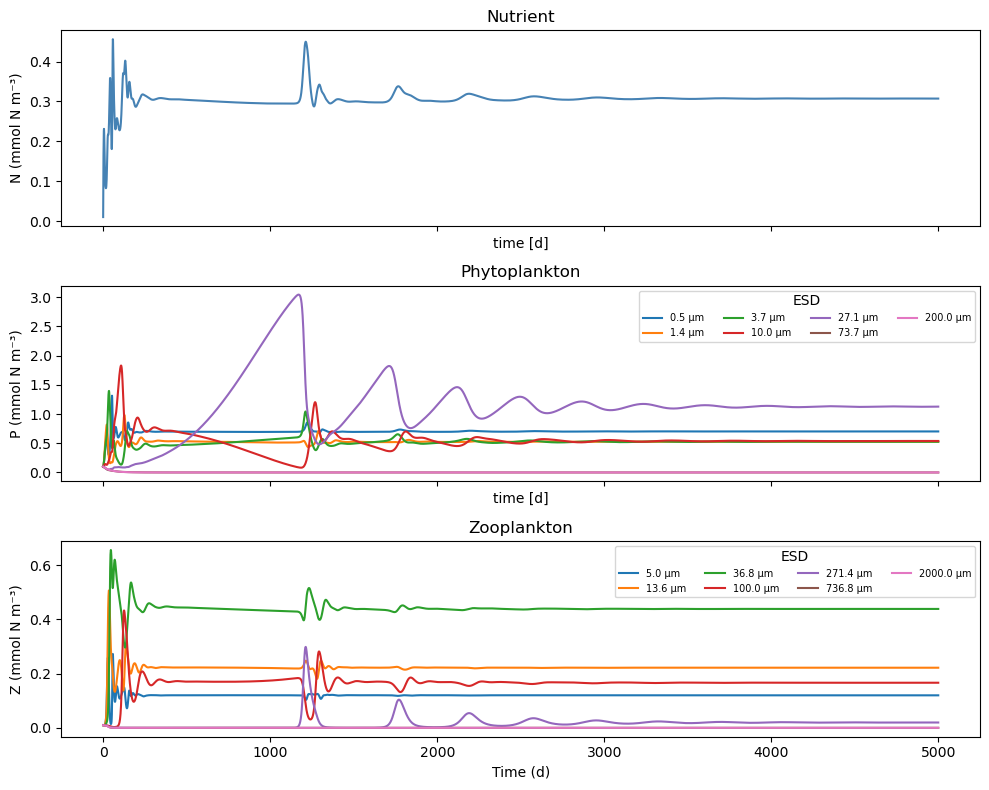

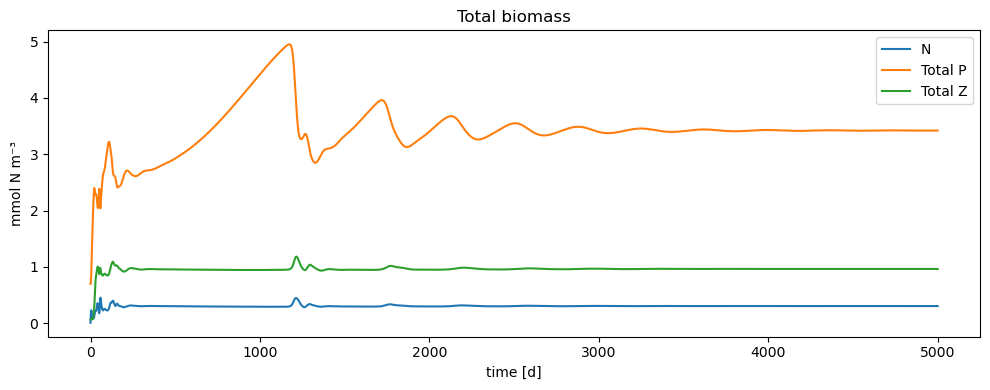


--- Final state (t = 4999 d) ---
  N:       0.3070
  Total P: 3.4210
  Total Z: 0.9654


In [165]:
# %% [markdown]
# ## 11. Quick diagnostic plots

# %%
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# --- Nutrient ---
ax = axes[0]
model_out['Nutrient__value'].plot(ax=ax, color='steelblue')
ax.set_ylabel('N (mmol N m⁻³)')
ax.set_title('Nutrient')

# --- Phytoplankton ---
ax = axes[1]
P = model_out['Phytoplankton__biomass']
for i, esd in enumerate(phyto_esd):
    P.isel(phyto=i).plot(ax=ax, label=f'{esd:.1f} µm')
ax.set_ylabel('P (mmol N m⁻³)')
ax.set_title('Phytoplankton')
ax.legend(fontsize=7, ncol=4, title='ESD')

# --- Zooplankton ---
ax = axes[2]
Z = model_out['Zooplankton__biomass']
for i, esd in enumerate(zoo_esd):
    Z.isel(zoo=i).plot(ax=ax, label=f'{esd:.1f} µm')
ax.set_ylabel('Z (mmol N m⁻³)')
ax.set_title('Zooplankton')
ax.legend(fontsize=7, ncol=4, title='ESD')

axes[-1].set_xlabel('Time (d)')
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 12. Total biomass summary

# %%
total_P = model_out['Phytoplankton__biomass'].sum(dim='phyto')
total_Z = model_out['Zooplankton__biomass'].sum(dim='zoo')
total_N = model_out['Nutrient__value']

fig, ax = plt.subplots(figsize=(10, 4))
total_N.plot(ax=ax, label='N')
total_P.plot(ax=ax, label='Total P')
total_Z.plot(ax=ax, label='Total Z')
ax.set_ylabel('mmol N m⁻³')
ax.set_title('Total biomass')
ax.legend()
plt.tight_layout()
plt.show()

# Print final-state summary
print(f"\n--- Final state (t = {float(model_out.time[-1]):.0f} d) ---")
print(f"  N:       {float(total_N[-1]):.4f}")
print(f"  Total P: {float(total_P[-1]):.4f}")
print(f"  Total Z: {float(total_Z[-1]):.4f}")

In [45]:
model_out

<xarray.Dataset> Size: 69MB
Dimensions:                              (time: 5000, phyto: 27, zoo: 27,
                                          full: 54, clock: 2)
Coordinates:
  * time                                 (time) float64 40kB 0.0 ... 4.999e+03
  * phyto                                (phyto) float64 216B 0.5 ... 200.0
  * zoo                                  (zoo) float64 216B 5.0 6.296 ... 2e+03
  * clock                                (clock) int64 16B 0 1
Dimensions without coordinates: full
Data variables: (12/60)
    Core__solver_type                    <U9 36B 'solve_ivp'
    FishForcing__forcing_label           <U9 36B 'F_forcing'
    FishForcing__forcing_value           (time) float64 40kB 1.0 1.0 ... 1.0 1.0
    FishForcing__value                   float64 8B 1.0
    FishGrazing__fish_forcing            <U9 36B 'F_forcing'
    FishGrazing__fish_graze_phyto_value  (phyto, time) float64 1MB 0.0 ... 0.0
    ...                                   ...
    ZooMortality__population             <U1 4B 'Z'
    ZooMortality__rate                   float64 8B 0.1
    Zooplankton__biomass                 (zoo, time) float64 1MB 0.01 ... 0.0
    Zooplankton__biomass_init            (zoo) float64 216B 0.01 0.01 ... 0.01
    Zooplankton__biomass_label           <U1 4B 'Z'
    Zooplankton__zoo_index               (zoo) float64 216B 5.0 6.296 ... 2e+03

In [48]:
model_out['PhytoMortality__mortality_value'].sum(dim='time')

<xarray.DataArray 'PhytoMortality__mortality_value' (phyto: 27)> Size: 216B
array([2.95205947e+02, 8.43523708e-02, 2.31178210e-02, 1.16591582e-02,
       7.52115418e-03, 5.52737382e-03, 4.39418299e-03, 3.67991896e-03,
       3.19881833e-03, 2.86159628e-03, 2.62157553e-03, 2.45371834e-03,
       2.34599394e-03, 2.29656281e-03, 2.31535043e-03, 2.43258382e-03,
       2.72700840e-03, 3.43906681e-03, 5.67769504e-03, 1.51265461e-02,
       4.50340507e-02, 1.06043665e-01, 1.69255079e-01, 5.01160258e-02,
       4.39129749e-04, 2.07665491e-04, 1.23968132e-04])
Coordinates:
  * phyto    (phyto) float64 216B 0.5 0.6296 0.7927 0.9982 ... 126.1 158.8 200.0
Attributes:
    description:    output of flux value / 
    xso_store_out:  True